# Does the Tape Agree With Itself? — a quantitative teardown \U0001F52C
### Resampling · total-return reconstruction · calendar coverage · splits · dividends · a planted-fault control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The design
constraint worth stating: with one provider you can prove a feed **contradicts itself**, never
that it is right. Every check here is therefore an internal identity, and the audit's own
sensitivity is established on a synthetic tape with faults planted at known positions.

> ⚠️ **Not investment advice.** Four flavours from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from tape_audit import data, strategy as st

tapes = {tk: data.load_all(tk) for tk in data.TICKERS}
calendar = st.build_calendar({tk: fr["daily_tr"] for tk, fr in tapes.items()})
print(f"as-of {data.AS_OF} | {len(tapes)} tickers x {len(data.FLAVOURS)} flavours")
print(f"reference calendar: {len(calendar):,} sessions "
      f"{calendar[0].date()} -> {calendar[-1].date()}")
for tk, fr in tapes.items():
    print(f"  {tk:6s} daily {len(fr['daily_tr']):5,}  weekly {len(fr['weekly']):5,}  "
          f"monthly {len(fr['monthly']):4,}")

as-of 2026-06-30 | 8 tickers x 4 flavours
reference calendar: 6,901 sessions 1999-01-22 -> 2026-06-30
  SPY    daily 8,411  weekly 1,745  monthly  402
  QQQ    daily 6,869  weekly 1,426  monthly  328
  AAPL   daily 8,430  weekly 1,748  monthly  402
  NVDA   daily 6,901  weekly 1,433  monthly  330
  TSLA   daily 4,025  weekly   836  monthly  193
  VYM    daily 4,933  weekly 1,025  monthly  236
  XLU    daily 6,921  weekly 1,437  monthly  331
  GLD    daily 5,436  weekly 1,129  monthly  260


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | The audit ran **62** checks across 8 tickers and returned **1 errors** and **3 warnings**. The weekly and monthly bars compound from the daily ones to within **4504 bps** at worst; rebuilding the total-return series from price plus dividends and splits reproduces the provider's own adjusted close to **+0.005%/yr** at worst (XLU); and the reference calendar shows **0** missing sessions in total. |
| **Usefulness** | Useful | The same buy-and-hold statistic computed from the daily tape and from the provider's own weekly bars differs by up to **0.052** of Sharpe and **+0.01%/yr** of CAGR (SPY) — most of which is the arithmetic of measuring volatility at a different frequency rather than a data fault. The fault that *would* change a published number is the reconstruction gap, and the audit prices it at +0.005%/yr. |

> \U0001F4A1 **In plain words.** The feed is coherent to a few basis points nearly everywhere.
> "Nearly" is why the audit exists, and the audit is cheap.

## 1 · The claim, as identities

- **I₁.** Compounding daily total returns over a week must equal the weekly bar's return.
- **I₂.** `adj_close` must equal `close` compounded with dividend reinvestment and split
  factors. (CRSP's definition; every provider claims to implement it.)
- **I₃.** A session traded by a majority of US equity tapes was a session; a tape missing it has
  a hole, a halt, or a listing gap.
- **I₄.** On a split date, the as-traded close moves by 1/ratio and the adjusted close does not
  move at all.

## 2 · So what? — the quantitative stakes

I₂ is the one with teeth. A 0.5%/yr error in the adjustment compounds to 5% of terminal wealth
over a decade, is identical across every strategy tested on that tape, and is undetectable by
any amount of statistical rigour applied downstream.

## 3 · How we'd know — the protocol

1. **One pass, four flavours**, timestamps recorded (`data.cache_dates`) so a disagreement
   cannot be blamed on fetching them weeks apart.
2. **Compare returns, not levels** — two series with different first observations are not in
   conflict, and comparing levels would report a fault on every row.
3. **Severities are declared, not implied**: *error* = a number computed from this tape will be
   wrong; *warning* = may be; *info* = expected.
4. **A planted-fault control** establishes the audit's own sensitivity.

## 4 · The teardown

### 4.1 The full audit

{'error': np.int64(1), 'warning': np.int64(3), 'info': np.int64(58)}


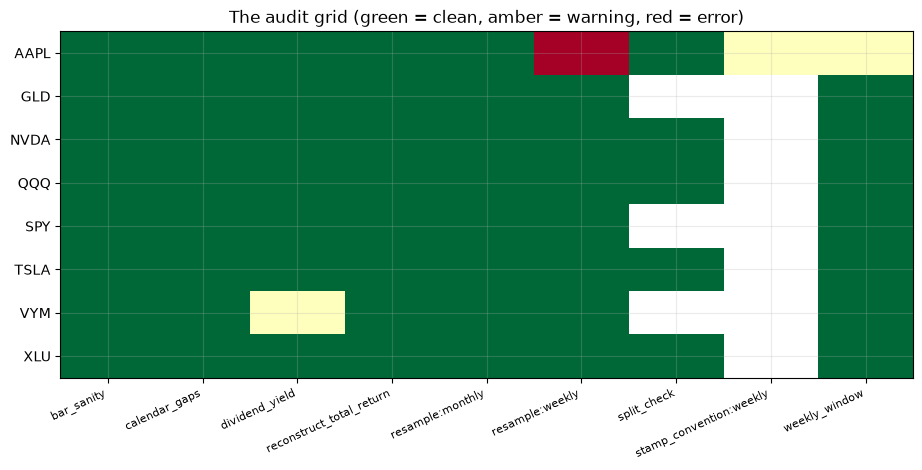

,ticker,check,severity,detail
15,AAPL,resample:weekly,error,1677 of 1744 periods differ by more than 10 bp...
16,AAPL,weekly_window,warning,Fri label -> closes Thu (+6 days) on 390/400 p...
17,AAPL,stamp_convention:weekly,warning,bars are stamped on Friday and match the daily...
45,VYM,dividend_yield,warning,total-minus-price CAGR is 3.30%/yr against 3.0...


In [3]:
findings = pd.concat([st.audit(fr, calendar, tk) for tk, fr in tapes.items()],
                     ignore_index=True)
counts = st.severity_counts(findings)
print(dict(counts))
piv = findings.pivot_table(index="ticker", columns="check", values="severity",
                           aggfunc=lambda s: s.iloc[0])
order = {"info": 0, "warning": 1, "error": 2}
num = piv.map(lambda s: order.get(s, np.nan))
fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(num.values, cmap="RdYlGn_r", vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(num.shape[1])); ax.set_xticklabels(num.columns, rotation=25, ha="right",
                                                       fontsize=8)
ax.set_yticks(range(num.shape[0])); ax.set_yticklabels(num.index)
ax.set_title("The audit grid (green = clean, amber = warning, red = error)")
plt.show()
findings[findings["severity"] != "info"][["ticker", "check", "severity", "detail"]]

### 4.2 Resampling, in detail

ticker    freq  n_periods  median_abs_diff_bps  max_abs_diff_bps  n_beyond_10bps   corr
   SPY  weekly 1,742.0000               0.0022            0.0270          0.0000 1.0000
   SPY monthly   399.0000               0.0022            0.0165          0.0000 1.0000
   QQQ  weekly 1,423.0000               0.0020            0.0170          0.0000 1.0000
   QQQ monthly   325.0000               0.0022            0.0121          0.0000 1.0000
  AAPL  weekly 1,744.0000             166.6736        4,503.5774      1,677.0000 0.7740
  AAPL monthly   399.0000               0.0020            0.0114          0.0000 1.0000
  NVDA  weekly 1,430.0000               0.0019            0.0160          0.0000 1.0000
  NVDA monthly   327.0000               0.0018            0.0086          0.0000 1.0000
  TSLA  weekly   833.0000               0.0000            0.0000          0.0000 1.0000
  TSLA monthly   190.0000               0.0000            0.0000          0.0000 1.0000
   VYM  weekly 1,022.0000       

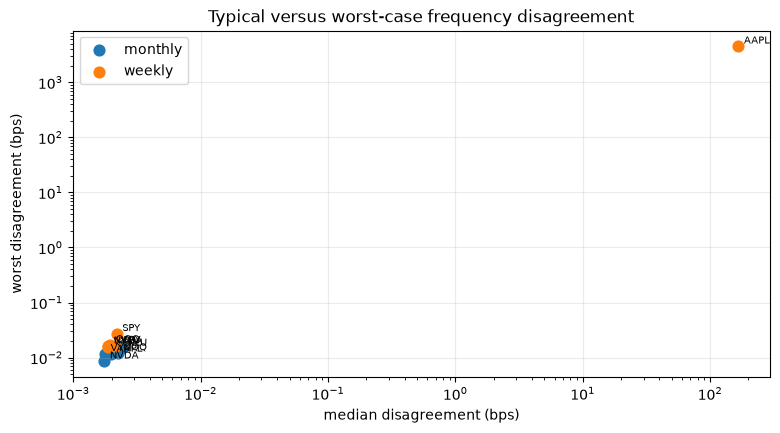

In [4]:
rows = []
for tk, fr in tapes.items():
    ra = st.resample_agreement(fr["daily_tr"], fr["weekly"], fr["monthly"])
    for f, r in ra.iterrows():
        rows.append({"ticker": tk, "freq": f, **{k: r[k] for k in
                     ("n_periods", "median_abs_diff_bps", "max_abs_diff_bps",
                      "n_beyond_10bps", "corr")}})
d = pd.DataFrame(rows)
print(d.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4.5))
for f, sub in d.groupby("freq"):
    ax.scatter(sub["median_abs_diff_bps"], sub["max_abs_diff_bps"], s=60, label=f)
    for _, r in sub.iterrows():
        ax.annotate(r["ticker"], (r["median_abs_diff_bps"], r["max_abs_diff_bps"]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("median disagreement (bps)"); ax.set_ylabel("worst disagreement (bps)")
ax.legend(); ax.set_title("Typical versus worst-case frequency disagreement")
plt.show()

### 4.3 The reconstruction, decomposed

        annualised gap  worst day (bps)  implied yield  reported yield  yield gap
ticker                                                                           
SPY             0.0000           2.6331         0.0198          0.0180     0.0017
QQQ             0.0000           0.7282         0.0069          0.0063     0.0007
AAPL           -0.0000           3.0645         0.0078          0.0064     0.0014
NVDA           -0.0000           0.9115         0.0044          0.0032     0.0012
TSLA           -0.0000           0.0000         0.0000          0.0000     0.0000
VYM            -0.0000           2.8818         0.0330          0.0308     0.0022
XLU            -0.0001           5.3309         0.0365          0.0345     0.0019
GLD            -0.0000           0.0000         0.0000          0.0000     0.0000


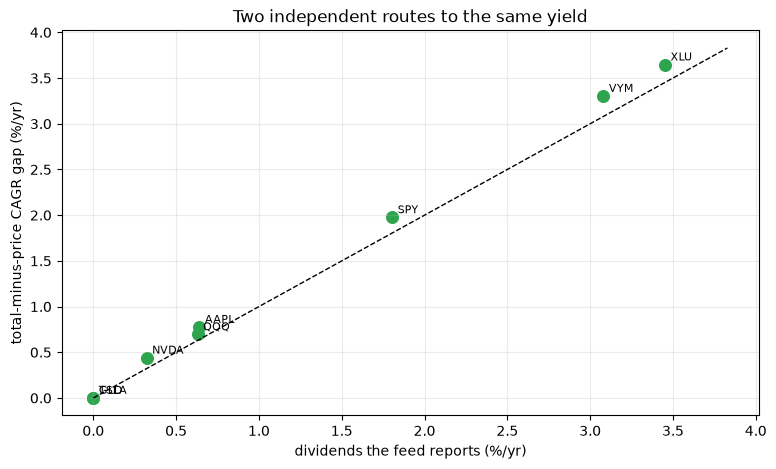

In [5]:
rows = []
for tk, fr in tapes.items():
    rec = st.reconstruct_total_return(fr["daily_raw"])
    dy = st.dividend_yield_check(fr["daily_raw"], fr["daily_tr"])
    if rec.get("available"):
        rows.append({"ticker": tk, "annualised gap": rec["annualised_gap"],
                     "worst day (bps)": rec["max_daily_diff_bps"],
                     "implied yield": dy["implied_yield"], "reported yield": dy["reported_yield"],
                     "yield gap": dy["gap"]})
d = pd.DataFrame(rows).set_index("ticker")
print(d.round(5).to_string())
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(d["reported yield"] * 100, d["implied yield"] * 100, s=70, color="#2ea44f")
lim = [0, max(d["implied yield"].max(), d["reported yield"].max()) * 105]
ax.plot(lim, lim, color="k", ls="--", lw=1)
for tk, r in d.iterrows():
    ax.annotate(tk, (r["reported yield"] * 100, r["implied yield"] * 100), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("dividends the feed reports (%/yr)")
ax.set_ylabel("total-minus-price CAGR gap (%/yr)")
ax.set_title("Two independent routes to the same yield")
plt.show()

> \U0001F4A1 **In plain words.** The two axes are computed from different columns of the feed:
> one from the event stream, one from the difference between two price series. Points on the
> diagonal mean the feed's own arithmetic is internally consistent.

### 4.4 Splits

ticker       date   ratio  raw_move  adjusted_move  raw_ok  adjusted_ok  looks_unadjusted
   QQQ 2000-03-20  2.0000    0.9720         0.9720    True         True             False
  AAPL 2000-06-21  2.0000    1.0990         1.0990    True         True             False
  AAPL 2005-02-28  2.0000    1.0080         1.0080    True         True             False
  AAPL 2014-06-09  7.0000    1.0160         1.0160    True         True             False
  AAPL 2020-08-31  4.0000    1.0340         1.0340    True         True             False
  NVDA 2000-06-27  2.0000    0.8590         0.8590    True         True             False
  NVDA 2001-09-10  2.0000    0.9710         0.9710    True         True             False
  NVDA 2006-04-07  2.0000    0.9970         0.9970    True         True             False
  NVDA 2007-09-11  1.5000    1.0210         1.0210    True         True             False
  NVDA 2021-07-20  4.0000    0.9910         0.9910    True         True             False
  NVDA 202

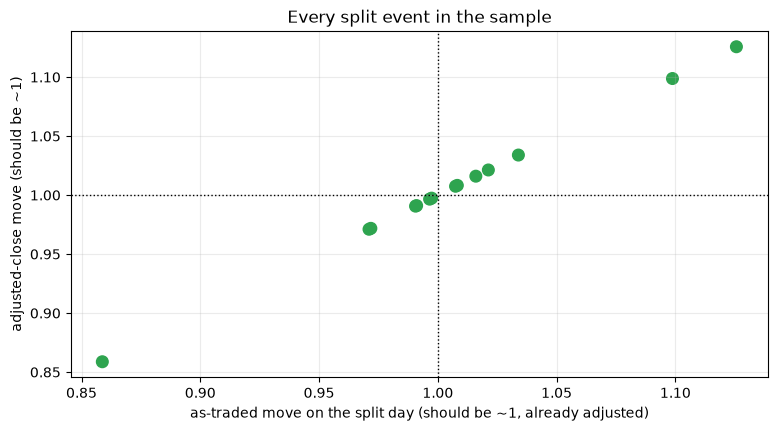

In [6]:
all_splits = []
for tk, fr in tapes.items():
    sc = st.split_check(fr["daily_raw"], fr["daily_tr"])
    if len(sc):
        sc.insert(0, "ticker", tk)
        all_splits.append(sc)
if all_splits:
    s = pd.concat(all_splits, ignore_index=True)
    print(s.round(3).to_string(index=False))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.scatter(s["raw_move"], s["adjusted_move"], s=70,
               c=["#2ea44f" if ok else "#c0392b" for ok in (s["raw_ok"] & s["adjusted_ok"])])
    ax.axhline(1, color="k", lw=1, ls=":"); ax.axvline(1, color="k", lw=1, ls=":")
    ax.set_xlabel("as-traded move on the split day (should be ~1, already adjusted)")
    ax.set_ylabel("adjusted-close move (should be ~1)")
    ax.set_title("Every split event in the sample")
    plt.show()

### 4.5 The control: does the audit fire when it should?

                  error  warning  info
tape                                  
clean                 0        0     8
missing session       0        1     7
unapplied split       1        0     7
missing dividend      0        0     8
all three             1        1     6


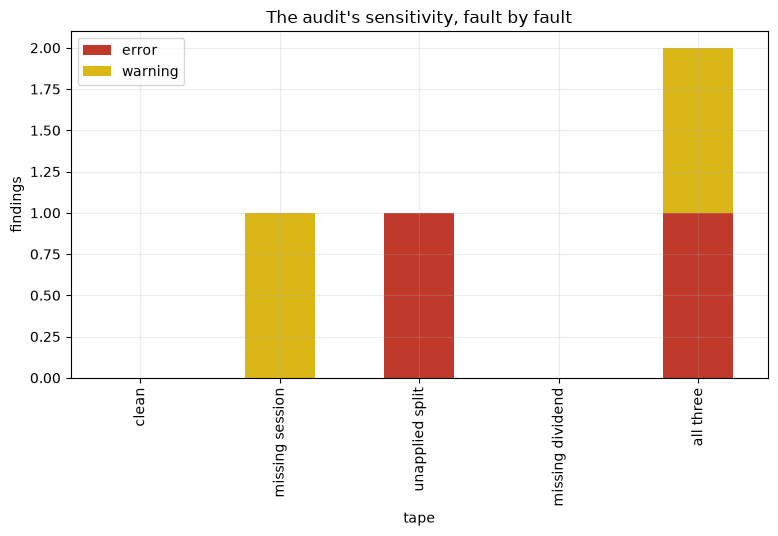

In [7]:
frames, truth = data.synthetic_tape(n_years=12, seed=971)
cal = st.build_calendar({"x": frames["daily_tr"]})
clean = st.audit(frames, cal, "CLEAN")
rows = [{"tape": "clean", **dict(st.severity_counts(clean))}]
for label, kwargs in (("missing session", dict(unapplied_split=False, drop_dividend=None)),
                      ("unapplied split", dict(drop_session=None, drop_dividend=None)),
                      ("missing dividend", dict(drop_session=None, unapplied_split=False)),
                      ("all three", {})):
    bf, planted = data.corrupt_tape(frames, **kwargs)
    rows.append({"tape": label, **dict(st.severity_counts(st.audit(bf, cal, label)))})
ctrl = pd.DataFrame(rows).set_index("tape")
print(ctrl.to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
ctrl[["error", "warning"]].plot.bar(ax=ax, color=["#c0392b", "#dab617"], stacked=True)
ax.set_ylabel("findings"); ax.set_title("The audit's sensitivity, fault by fault")
ax.legend(title="")
plt.show()

### 4.6 What a reader would inherit

        cagr_daily  cagr_weekly  cagr_gap  vol_daily  vol_weekly  sharpe_daily  sharpe_weekly  sharpe_gap
ticker                                                                                                   
SPY         0.1082       0.1081    0.0001     0.1858      0.1703        0.5825         0.6346     -0.0521
QQQ         0.1096       0.1091    0.0005     0.2695      0.2442        0.4067         0.4465     -0.0398
AAPL        0.2155       0.2162   -0.0007     0.4206      0.4194        0.5124         0.5155     -0.0031
NVDA        0.3672       0.3657    0.0015     0.5930      0.6021        0.6192         0.6074      0.0118
TSLA        0.4169       0.4304   -0.0135     0.5736      0.5556        0.7267         0.7747     -0.0480
VYM         0.0929       0.0933   -0.0004     0.1813      0.1682        0.5122         0.5544     -0.0422
XLU         0.0776       0.0774    0.0002     0.1925      0.1813        0.4031         0.4271     -0.0240
GLD         0.1029       0.1037   -0.0008     

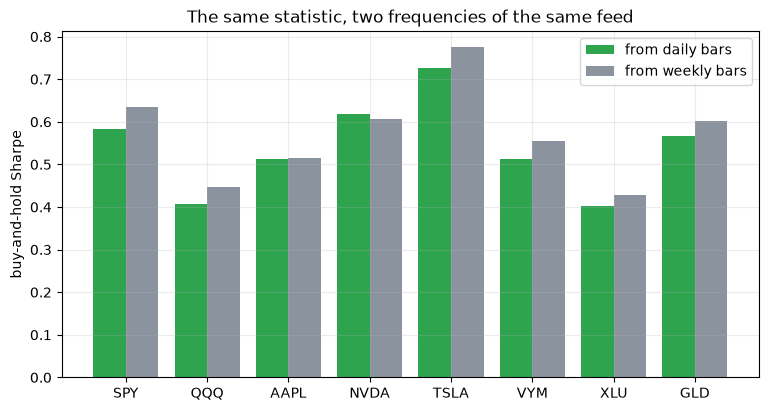

In [8]:
rows = []
for tk, fr in tapes.items():
    imp = st.backtest_impact(fr["daily_tr"], fr["weekly"])
    rows.append({"ticker": tk, **imp})
d = pd.DataFrame(rows).set_index("ticker")
print(d[["cagr_daily", "cagr_weekly", "cagr_gap", "vol_daily", "vol_weekly",
         "sharpe_daily", "sharpe_weekly", "sharpe_gap"]].round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(d))
ax.bar(x - 0.2, d["sharpe_daily"], width=0.4, color="#2ea44f", label="from daily bars")
ax.bar(x + 0.2, d["sharpe_weekly"], width=0.4, color="#8b949e", label="from weekly bars")
ax.set_xticks(x); ax.set_xticklabels(d.index)
ax.set_ylabel("buy-and-hold Sharpe"); ax.legend()
ax.set_title("The same statistic, two frequencies of the same feed")
plt.show()

> \U0001F4A1 **In plain words.** Most of this gap is not a data fault — measuring volatility
> weekly genuinely differs from measuring it daily unless returns are independent (study 970).
> The audit's job is to tell you which part is arithmetic and which part is a hole.

## 5 · The verdict

In [9]:
summary = pd.DataFrame({
    "checks run": [len(findings)],
    "errors": [int(st.severity_counts(findings)["error"])],
    "warnings": [int(st.severity_counts(findings)["warning"])],
    "worst resample (bps)": [max(st.resample_agreement(fr["daily_tr"], fr["weekly"],
                                                       fr["monthly"])["max_abs_diff_bps"].max()
                                 for fr in tapes.values())],
    "worst reconstruction (%/yr)": [max(abs(st.reconstruct_total_return(
        fr["daily_raw"]).get("annualised_gap", 0)) for fr in tapes.values()) * 100],
}).T.rename(columns={0: "value"})
summary.round(4)

,value
checks run,62.0000
errors,1.0000
warnings,3.0000
worst resample (bps),"4,503.5774"
worst reconstruction (%/yr),0.0050


## 6 · What to actually do

Run this once per provider, keep the fingerprints, and re-run it when the numbers move. It
takes a minute and it converts "I hope the data is fine" into a checked claim with a date on it.

## 7 · Going further

- **A second provider** (Stooq, Tiingo, a broker API) upgrades self-consistency to
  cross-validation.
- **A real exchange calendar** (`pandas_market_calendars`) catches the sessions that are
  missing from every tape at once.
- **Ince & Porter's screens** for individual equities — return reversals that are pure data
  error — are the natural extension to a wide cross-section.
- **Point-in-time capture**: none of this detects *restatement*, where the feed silently
  rewrites history. Only storing your own snapshots does.